# Executive Summary — Telecom Churn Prediction

# 📄 1. 문제 정의 및 데이터 이해

1) 계정 & 요금제
컬럼명	설명
state	고객 거주 주/지역 코드
account length	계정 유지 기간 (월 수)
area code	지역 전화 코드
international plan	국제 요금제 가입 여부
voice mail plan	음성메일 서비스 이용 여부
number vmail messages	음성메일 메시지 수

2) 통화량/통화패턴
컬럼명	설명
total day minutes	낮 통화 사용량 (분)
total day calls	낮 통화 횟수
total day charge	낮 통화 요금
total eve minutes / calls / charge	저녁 통화 패턴
total night minutes / calls / charge	야간 통화 패턴
total intl minutes / calls / charge	국제 통화 패턴

3) 고객 행동 변수
컬럼명	설명
customer service calls	고객센터 연락 횟수

## 데이터 요약 (요약정리)
특성	설명
총 관측치	2,666명 고객 (Rows)
총 컬럼	20개 특성 + 1개 타겟(churn)
타겟 타입	이진 분류 (True/False)
데이터 출처	Orange Telecom 이탈 데이터셋 (Kaggle/BigML 기반)

churn-bigml-80.csv는 Orange Telecom 고객의 요금제, 이용 패턴, 서비스 행동 정보를 포함한 이탈 예측 데이터셋입니다.
전체 2,666명의 고객 데이터를 포함하고, 20개의 설명변수(features)와 이탈 여부(churn)라는 이진 타겟을 갖고 있어서
머신러닝 모델을 통해 고객 이탈을 예측하고 유지 전략을 수립하는 데 적합한 구조

# 📄 2. 데이터 전처리

In [ ]:
import pandas as pd
import numpy as np

# ===============================
# 1. 데이터 불러오기
# ===============================
df = pd.read_csv("churn-bigml-80.csv")
print("원본 데이터 크기:", df.shape)

# ===============================
# 2. 결측치 확인
# ===============================
missing = df.isnull().sum()
print("\n[결측치 개수]")
print(missing[missing > 0])

# → 해당 데이터셋은 결측치 없음

# ===============================
# 3. 불필요한 컬럼 제거
# ===============================
# phone number는 고유 식별자 → 제거
if "phone number" in df.columns:
    df.drop(columns=["phone number"], inplace=True)

# ===============================
# 4. 타겟 변수 변환
# ===============================
# Churn: True / False → 1 / 0
df["Churn"] = df["Churn"].map({True: 1, False: 0})

# ===============================
# 5. 이진 범주형 변수 처리 (에러 방지 핵심)
# ===============================
binary_cols = ["International plan", "Voice mail plan"]

for col in binary_cols:
    if col in df.columns:
        # 문자열일 경우만 yes/no 매핑
        if df[col].dtype == "object":
            df[col] = df[col].map({"yes": 1, "no": 0})
        
        # NaN 방지 후 정수 변환
        df[col] = df[col].fillna(0).astype(int)

# ===============================
# 6. 범주형 변수 인코딩
# ===============================
# Area code가 숫자여도 범주형 의미 → 문자열 변환
if "Area code" in df.columns:
    df["Area code"] = df["Area code"].astype(str)

categorical_cols = ["State", "Area code"]

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("\n인코딩 후 데이터 크기:", df.shape)

# ===============================
# 7. 이상치 확인 (요약 통계)
# ===============================
numeric_cols = df.select_dtypes(include=["int64", "float64"])

print("\n[수치형 변수 요약 통계]")
print(numeric_cols.describe())

# → 통화량/요금의 큰 값은 실제 사용량 차이로 판단
# → 이상치 제거하지 않음

# ===============================
# 8. 최종 데이터 확인
# ===============================
print("\n전처리 완료 데이터 정보")
print(df.info())


원본 데이터 크기: (2666, 20)

[결측치 개수]
Series([], dtype: int64)

인코딩 후 데이터 크기: (2666, 70)

[수치형 변수 요약 통계]
       Account length  International plan  Voice mail plan  \
count     2666.000000              2666.0           2666.0   
mean       100.620405                 0.0              0.0   
std         39.563974                 0.0              0.0   
min          1.000000                 0.0              0.0   
25%         73.000000                 0.0              0.0   
50%        100.000000                 0.0              0.0   
75%        127.000000                 0.0              0.0   
max        243.000000                 0.0              0.0   

       Number vmail messages  Total day minutes  Total day calls  \
count            2666.000000         2666.00000      2666.000000   
mean                8.021755          179.48162       100.310203   
std                13.612277           54.21035        19.988162   
min                 0.000000            0.00000         0.000000   
25

# 📄 3. EDA


3-1) 단변량 분석

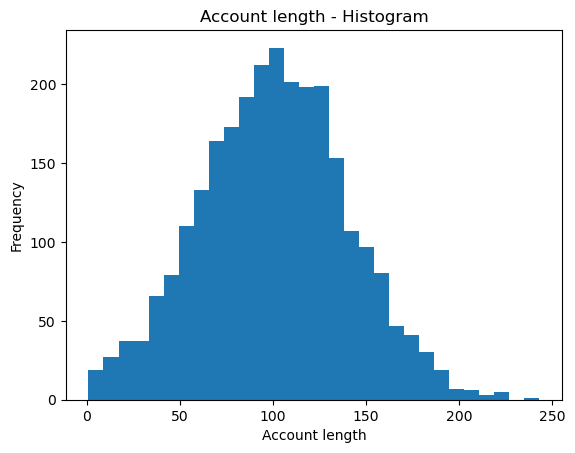

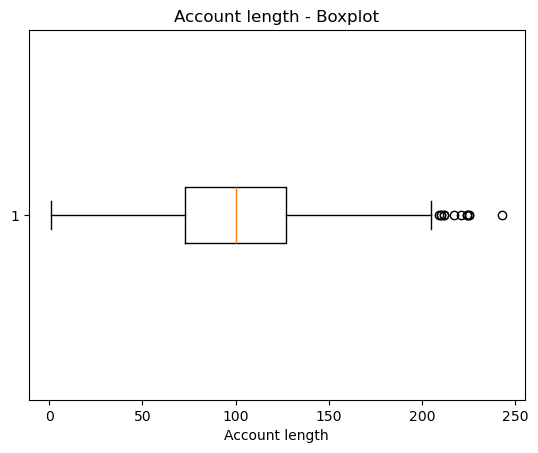

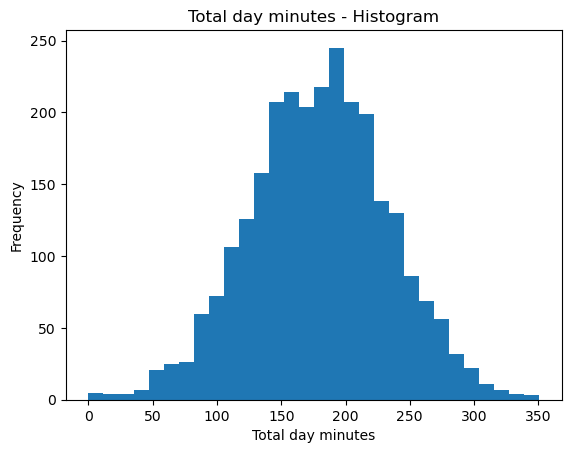

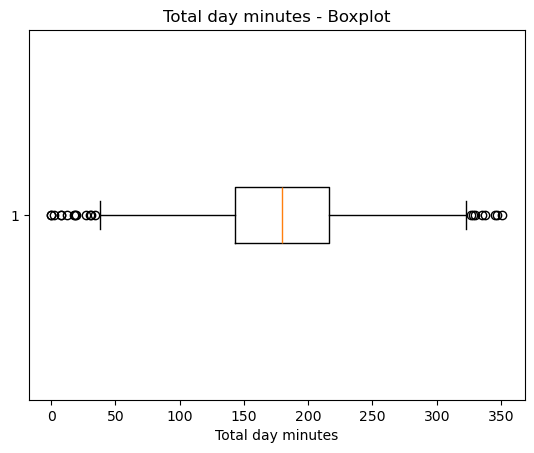

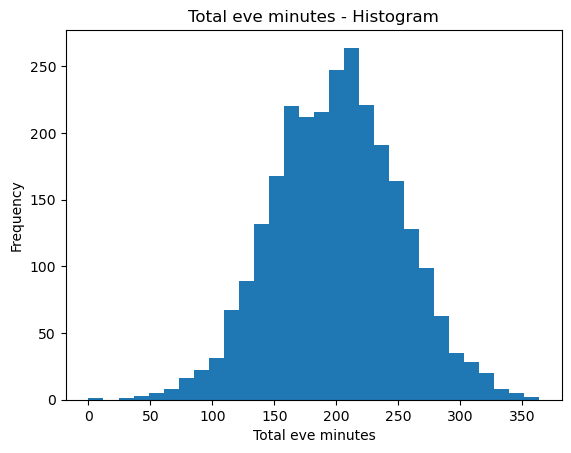

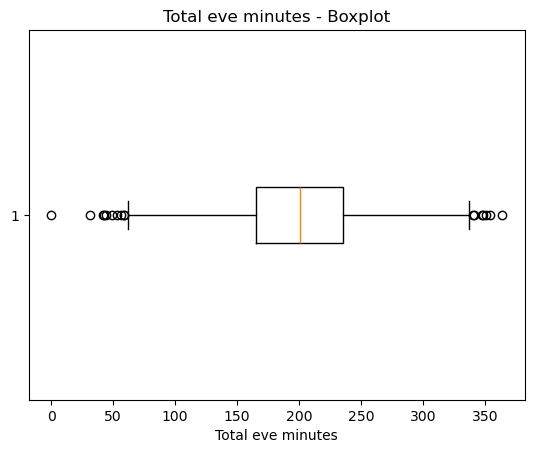

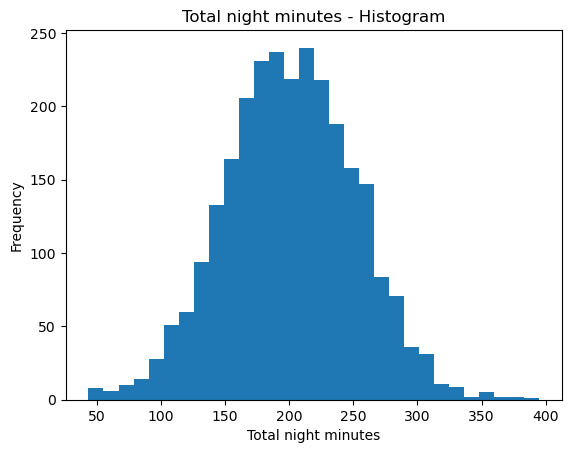

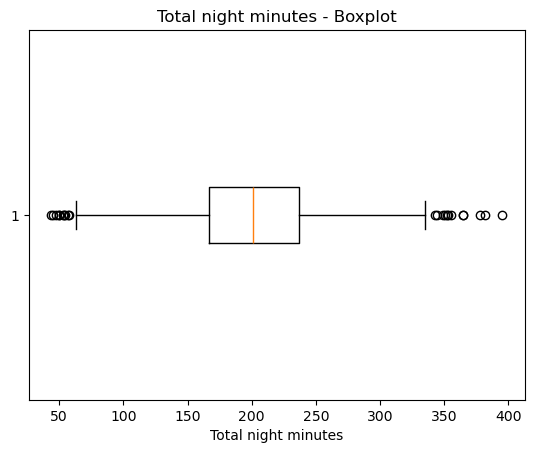

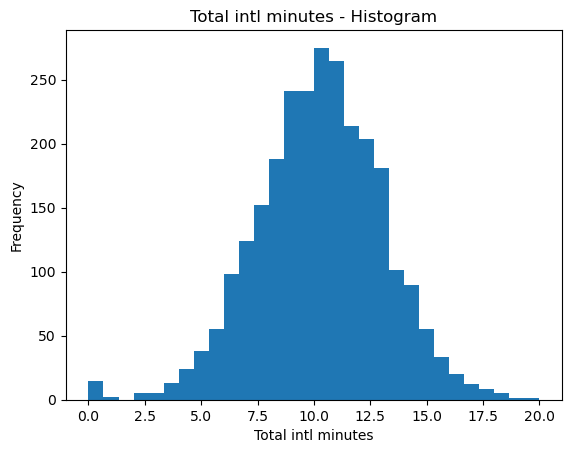

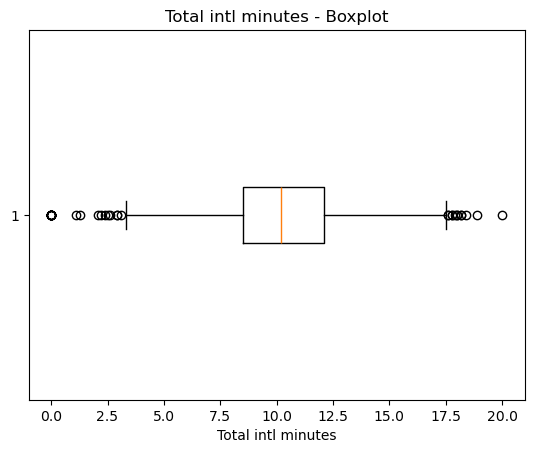

In [30]:
# 히스토그램 & 박스플롯

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("churn-bigml-80.csv")

num_cols = [
    "Account length",
    "Total day minutes",
    "Total eve minutes",     
    "Total night minutes",
    "Total intl minutes"
]

# (에러 방지) 컬럼 존재 체크
missing = [c for c in num_cols if c not in df.columns]
if missing:
    print("❌ 아래 컬럼이 CSV에 없습니다:", missing)
else:
    for col in num_cols:
        # 히스토그램
        plt.figure()
        plt.hist(df[col], bins=30)
        plt.title(f"{col} - Histogram")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.show()

        # 박스플롯
        plt.figure()
        plt.boxplot(df[col], vert=False)
        plt.title(f"{col} - Boxplot")
        plt.xlabel(col)
        plt.show()


In [31]:
# 기술통계량 산출

import pandas as pd

num_cols = [
    "Account length",
    "Total day minutes",
    "Total eve minutes",
    "Total night minutes",
    "Total intl minutes"
]

# 1) 누락 컬럼 체크
missing = [c for c in num_cols if c not in df.columns]
if missing:
    print("❌ CSV에 없는 컬럼:", missing)

# 2) 존재하는 컬럼만으로 통계 산출 (에러 방지)
valid_num_cols = [c for c in num_cols if c in df.columns]

stats = (
    df[valid_num_cols]
    .describe()
    .T[["mean", "50%", "std", "25%", "75%"]]
    .rename(columns={"50%": "median"})
)

stats


,mean,median,std,25%,75%
Account length,100.620405,100.00,39.563974,73.000,127.000
Total day minutes,179.481620,179.95,54.210350,143.400,215.900
Total eve minutes,200.386159,200.90,50.951515,165.300,235.100
Total night minutes,201.168942,201.15,50.780323,166.925,236.475
Total intl minutes,10.237022,10.20,2.788349,8.500,12.100



[State Frequency]
State
WV    88
MN    70
NY    68
VA    67
AL    66
OH    66
WY    66
OR    62
NV    61
WI    61
MD    60
UT    60
CO    59
CT    59
MI    58
VT    57
ID    56
NC    56
TX    55
FL    54
IN    54
MT    53
OK    52
MA    52
KS    52
MO    51
DE    51
NJ    50
SC    49
SD    49
ME    49
GA    49
RI    48
MS    48
WA    48
AR    47
IL    45
DC    45
AZ    45
NE    45
HI    44
NM    44
ND    44
AK    43
KY    43
NH    43
TN    41
IA    38
PA    36
LA    35
CA    24
Name: count, dtype: int64


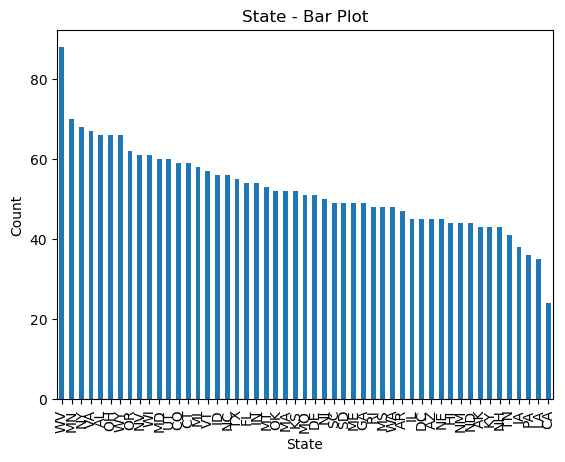


[International plan Frequency]
International plan
No     2396
Yes     270
Name: count, dtype: int64


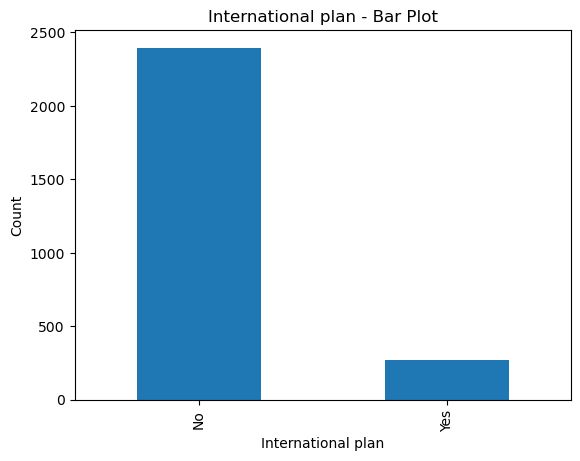


[Voice mail plan Frequency]
Voice mail plan
No     1933
Yes     733
Name: count, dtype: int64


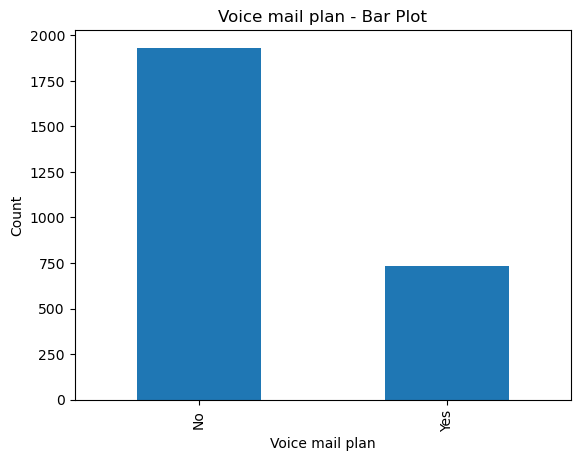

In [32]:
# 범주형 변수

cat_cols = [
    "State",
    "International plan",
    "Voice mail plan"
]

for col in cat_cols:
    # 빈도표
    print(f"\n[{col} Frequency]")
    print(df[col].value_counts())

    # 막대그래프
    plt.figure()
    df[col].value_counts().plot(kind="bar")
    plt.title(f"{col} - Bar Plot")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()


Churn Counts
Churn
False    2278
True      388
Name: count, dtype: int64

Churn Ratios (%)
Churn
False    85.446362
True     14.553638
Name: proportion, dtype: float64


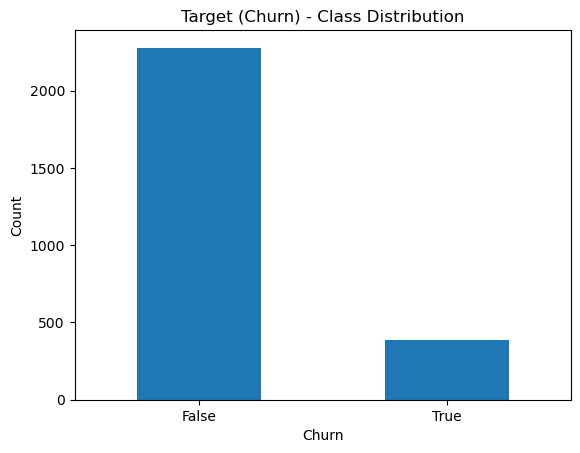


Imbalance Ratio (Majority / Minority): 5.87


In [33]:
# 타겟 변수 # Churn 분포

churn_counts = df["Churn"].value_counts()
churn_ratios = df["Churn"].value_counts(normalize=True) * 100

print("Churn Counts")
print(churn_counts)

print("\nChurn Ratios (%)")
print(churn_ratios)

# 시각화
plt.figure()
churn_counts.plot(kind="bar")
plt.title("Target (Churn) - Class Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

# 불균형 비율
imbalance_ratio = churn_counts.max() / churn_counts.min()
print(f"\nImbalance Ratio (Majority / Minority): {imbalance_ratio:.2f}")


3-2) 이변량 분석

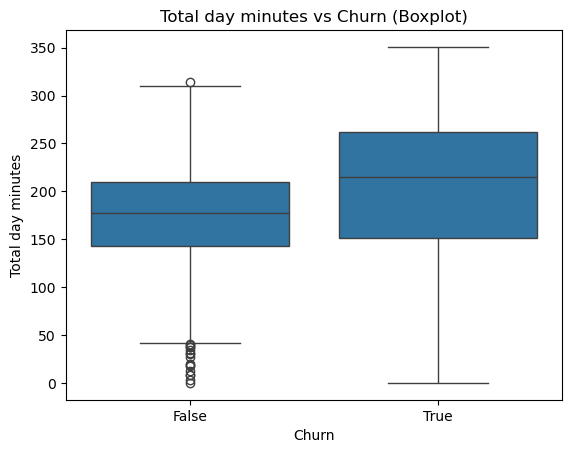

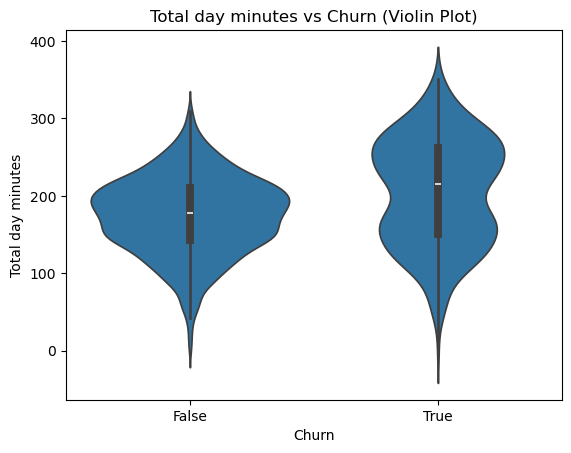

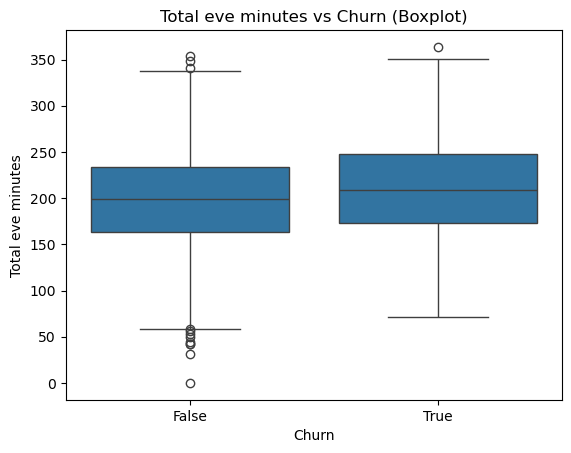

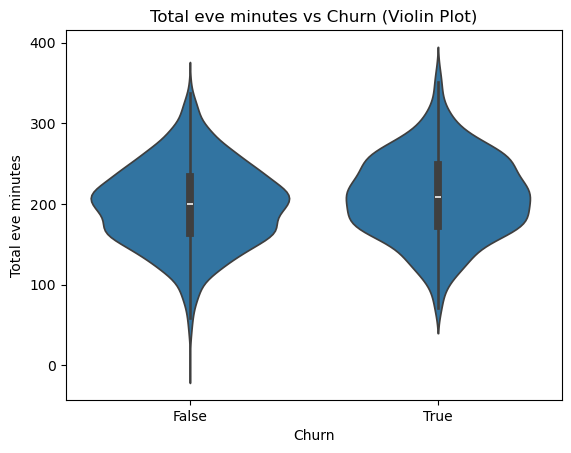

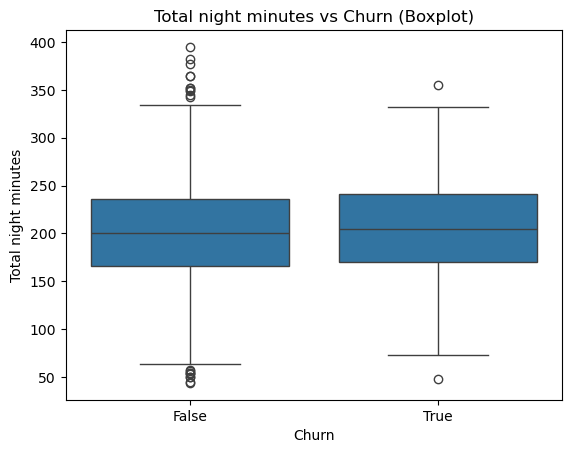

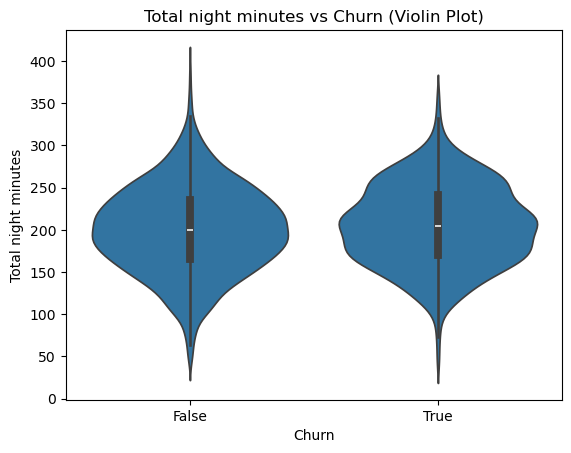

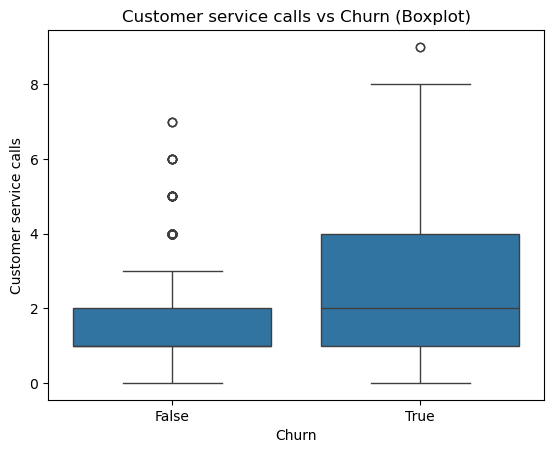

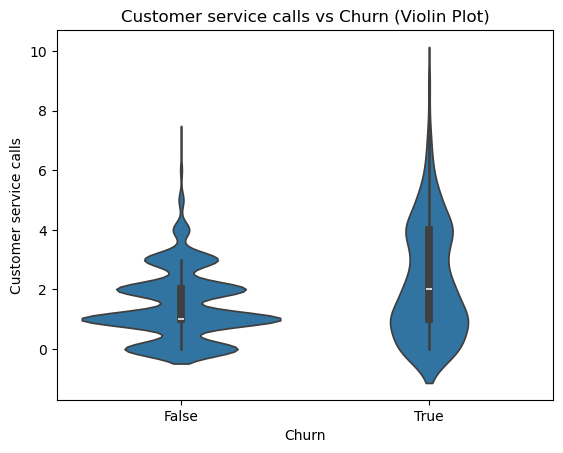

In [1]:
# 박스플롯 & 바이올린 플롯

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns   
df = pd.read_csv("churn-bigml-80.csv")

num_cols = [
    "Total day minutes",
    "Total eve minutes",
    "Total night minutes",
    "Customer service calls"
]

for col in num_cols:
    # Boxplot
    plt.figure()
    sns.boxplot(x="Churn", y=col, data=df)
    plt.title(f"{col} vs Churn (Boxplot)")
    plt.show()

    # Violin plot
    plt.figure()
    sns.violinplot(x="Churn", y=col, data=df)
    plt.title(f"{col} vs Churn (Violin Plot)")
    plt.show()




[International plan vs Churn Crosstab]
Churn                  False     True 
International plan                    
No                  0.887312  0.112688
Yes                 0.562963  0.437037


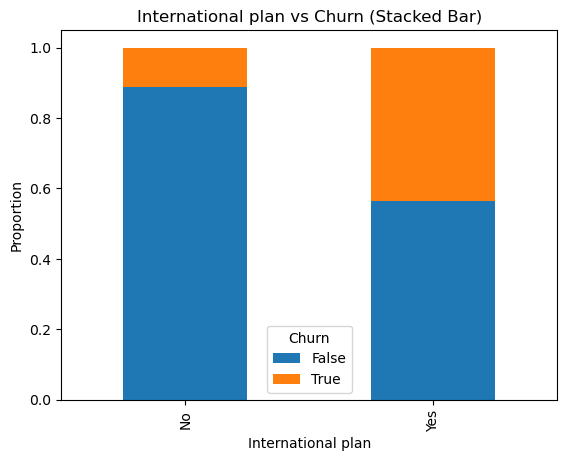


[Voice mail plan vs Churn Crosstab]
Churn               False     True 
Voice mail plan                    
No               0.832902  0.167098
Yes              0.911323  0.088677


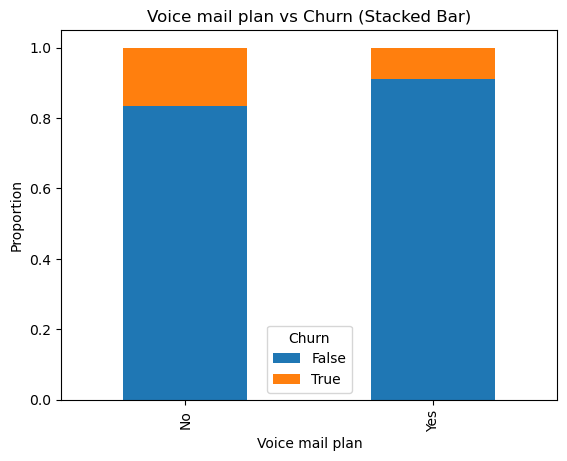

In [35]:
# 범주형 변수 VS Churn

cat_cols = [
    "International plan",
    "Voice mail plan"
]

for col in cat_cols:
    # 교차표
    ct = pd.crosstab(df[col], df["Churn"], normalize="index")
    print(f"\n[{col} vs Churn Crosstab]")
    print(ct)

    # 스택 바 차트
    ct.plot(kind="bar", stacked=True)
    plt.title(f"{col} vs Churn (Stacked Bar)")
    plt.ylabel("Proportion")
    plt.show()


In [36]:
# 통계적 검정/t-test — 수치형 변수

from scipy.stats import ttest_ind

num_cols = [
    "Total day minutes",
    "Total eve minutes",
    "Total night minutes",
    "Customer service calls"
]

for col in num_cols:
    churn_yes = df.loc[df["Churn"] == True, col]
    churn_no  = df.loc[df["Churn"] == False, col]

    t_stat, p_val = ttest_ind(churn_yes, churn_no, equal_var=False)

    print(f"[t-test: {col}]")
    print(f"t-statistic = {t_stat:.3f}, p-value = {p_val:.4f}\n")


[t-test: Total day minutes]
t-statistic = 8.281, p-value = 0.0000

[t-test: Total eve minutes]
t-statistic = 3.771, p-value = 0.0002

[t-test: Total night minutes]
t-statistic = 1.832, p-value = 0.0674

[t-test: Customer service calls]
t-statistic = 7.641, p-value = 0.0000



In [37]:
# Chi-square test/범주형 변수

from scipy.stats import chi2_contingency

cat_cols = [
    "International plan",
    "Voice mail plan"
]

for col in cat_cols:
    table = pd.crosstab(df[col], df["Churn"])

    chi2, p, dof, expected = chi2_contingency(table)

    print(f"[Chi-square test: {col}]")
    print(f"Chi2 = {chi2:.3f}, p-value = {p:.4f}\n")



[Chi-square test: International plan]
Chi2 = 202.682, p-value = 0.0000

[Chi-square test: Voice mail plan]
Chi2 = 25.656, p-value = 0.0000



In [38]:
# 고객센터 호출 횟수 기준 이탈률
cs_churn_rate = (
    df.assign(high_cs = df["Customer service calls"] >= 4)
      .groupby("high_cs")["Churn"]
      .mean() * 100
)

cs_churn_rate


high_cs
False    11.278502
True     52.857143
Name: Churn, dtype: float64

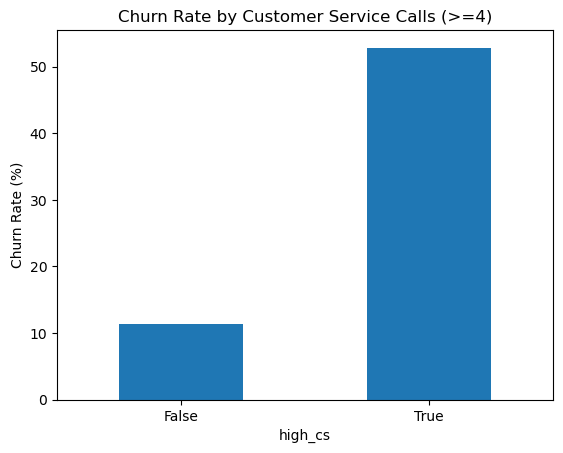

In [39]:
# 시각화
cs_churn_rate.plot(kind="bar")
plt.title("Churn Rate by Customer Service Calls (>=4)")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()


3-3) 다변량 분석

Shape: (2666, 20)
  State  Account length  Area code International plan Voice mail plan  \
0    KS             128        415                 No             Yes   
1    OH             107        415                 No             Yes   
2    NJ             137        415                 No              No   
3    OH              84        408                Yes              No   
4    OK              75        415                Yes              No   

   Number vmail messages  Total day minutes  Total day calls  \
0                     25              265.1              110   
1                     26              161.6              123   
2                      0              243.4              114   
3                      0              299.4               71   
4                      0              166.7              113   

   Total day charge  Total eve minutes  Total eve calls  Total eve charge  \
0             45.07              197.4               99             16.78   
1   

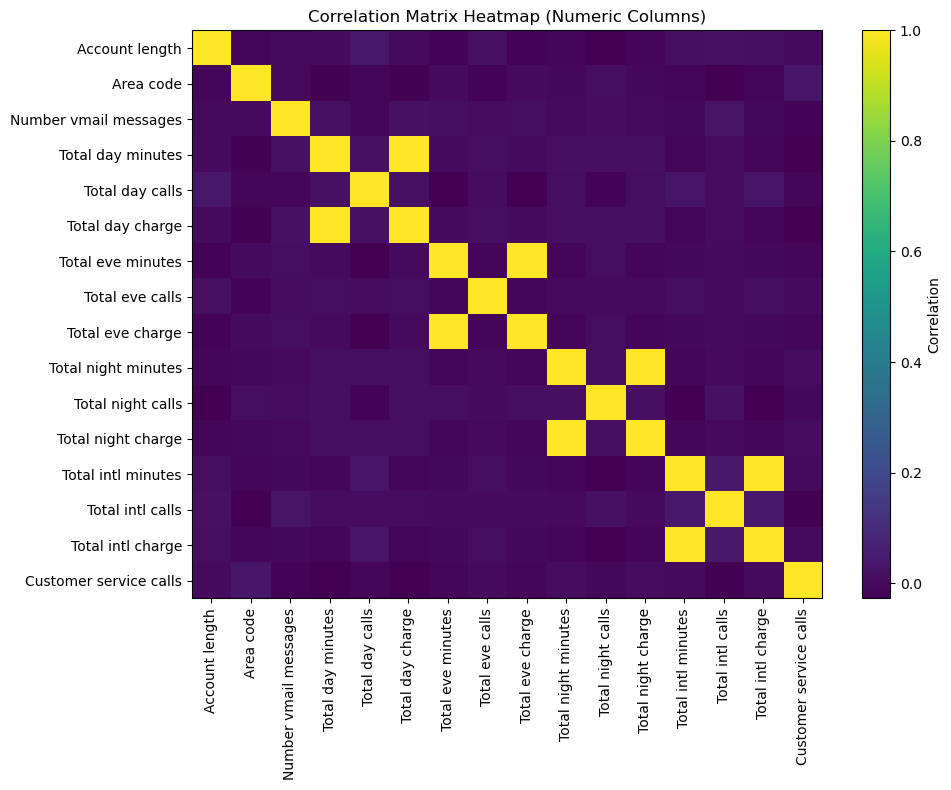


Top absolute correlations (Top 10):
Total day minutes    Total day charge          1.000000
Total eve minutes    Total eve charge          1.000000
Total night minutes  Total night charge        0.999999
Total intl minutes   Total intl charge         0.999993
Account length       Total day calls           0.038862
Total intl calls     Total intl charge         0.037363
Total intl minutes   Total intl calls          0.037315
Area code            Customer service calls    0.034442
Total day calls      Total intl charge         0.031133
                     Total intl minutes        0.031036
dtype: float64

VIF (Top 15):
                  variable           VIF
5         Total day charge  1.245859e+08
3        Total day minutes  1.245811e+08
8         Total eve charge  3.779054e+07
6        Total eve minutes  3.778888e+07
9      Total night minutes  1.081542e+07
11      Total night charge  1.081538e+07
14       Total intl charge  9.899192e+05
12      Total intl minutes  9.895024e+05
1   

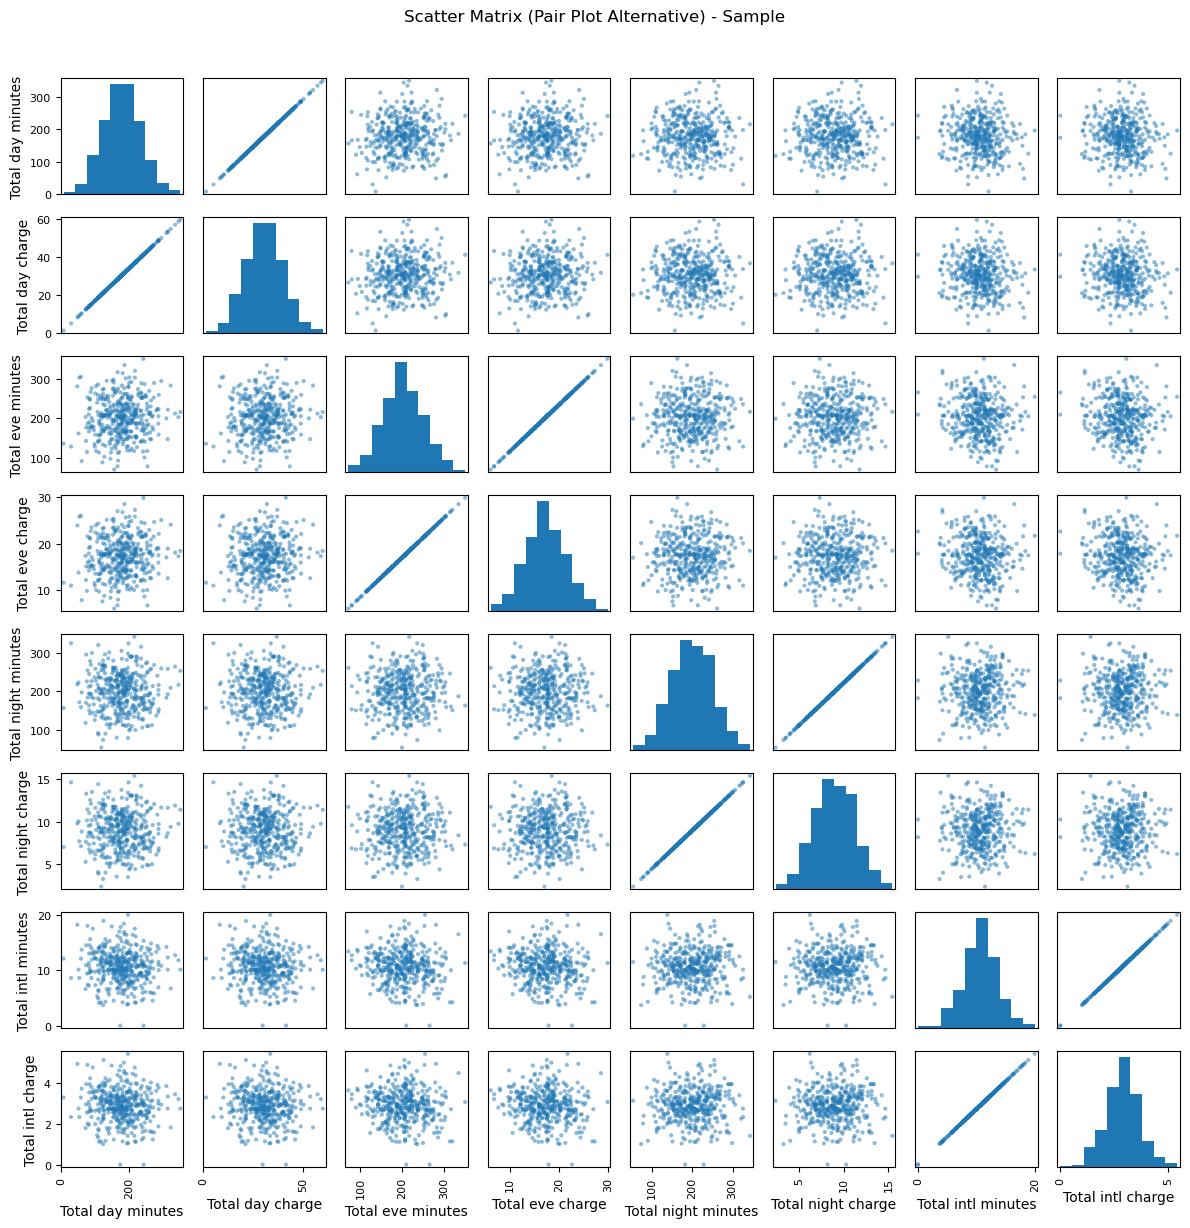

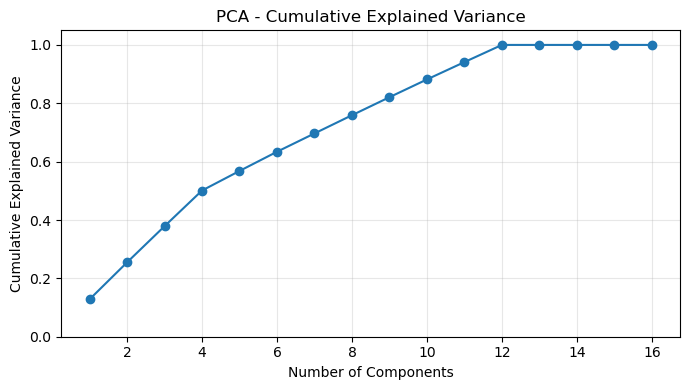


PCA Loadings (first rows):
                            PC1       PC2       PC3
Account length        -0.013275 -0.020861  0.013387
Area code             -0.011392  0.007192 -0.039042
Number vmail messages  0.017872  0.018595  0.019560
Total day minutes      0.431669  0.084331  0.483467
Total day calls       -0.001156 -0.049454  0.040438

Top 5 contributing variables per PC (by absolute loading):

PC1 Top 5:
Total day charge       0.431672
Total day minutes      0.431669
Total night minutes    0.411165
Total night charge     0.411157
Total intl minutes     0.377254
Name: PC1, dtype: float64

PC2 Top 5:
Total eve charge       0.564133
Total eve minutes      0.564127
Total night charge     0.306346
Total night minutes    0.306326
Total intl charge      0.280332
Name: PC2, dtype: float64

PC3 Top 5:
Total intl charge     0.488583
Total intl minutes    0.488533
Total day minutes     0.483467
Total day charge      0.483466
Total eve minutes     0.146662
Name: PC3, dtype: float64


In [40]:
# 상관관계 매트릭스 + 히트맵/다중공선성 확인/Pair Plo/PCA

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from statsmodels.stats.outliers_influence import variance_inflation_factor

# =========================
# 0) 데이터 로드
# =========================
path = "/mnt/data/churn-bigml-80.csv"
df = pd.read_csv("churn-bigml-80.csv")


print("Shape:", df.shape)
print(df.head())

# 수치형 컬럼만 (상관, VIF, PCA는 수치형 기반)
num_df = df.select_dtypes(include="number")

# =========================
# 1) 상관관계 매트릭스 + 히트맵(Heatmap)
# =========================
corr = num_df.corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr.values, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Correlation Matrix Heatmap (Numeric Columns)")
plt.tight_layout()
plt.show()

# (옵션) 가장 높은 상관 Top 10 보기 (자기 자신 제외)
abs_corr = corr.abs()
upper = abs_corr.where(np.triu(np.ones(abs_corr.shape), k=1).astype(bool))
top_pairs = upper.stack().sort_values(ascending=False).head(10)
print("\nTop absolute correlations (Top 10):")
print(top_pairs)

# =========================
# 2) 다중공선성 확인: VIF (Variance Inflation Factor)
# =========================
X = num_df.dropna().copy()

vif_df = pd.DataFrame({
    "variable": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
}).sort_values("VIF", ascending=False)

print("\nVIF (Top 15):")
print(vif_df.head(15))

# =========================
# 3) Pair Plot (대체): Scatter Matrix
#    - seaborn pairplot 대신 pandas scatter_matrix 사용
#    - 너무 느려지는 걸 막기 위해 샘플링
# =========================
cols_for_pairs = [
    "Total day minutes", "Total day charge",
    "Total eve minutes", "Total eve charge",
    "Total night minutes", "Total night charge",
    "Total intl minutes", "Total intl charge",
]
cols_for_pairs = [c for c in cols_for_pairs if c in df.columns]

sample = df[cols_for_pairs].dropna().sample(
    n=min(400, len(df)), random_state=42
)

scatter_matrix(sample, figsize=(12, 12), diagonal="hist")
plt.suptitle("Scatter Matrix (Pair Plot Alternative) - Sample", y=1.02)
plt.tight_layout()
plt.show()

# =========================
# 4) PCA (선택): 차원 축소 + 주요 성분 해석
# =========================
# 표준화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# 누적 설명분산
cum = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(cum) + 1), cum, marker="o")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA - Cumulative Explained Variance")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 로딩(주성분 기여도) 확인: 상위 3개 PC
n_show = 3
loadings = pd.DataFrame(
    pca.components_.T[:, :n_show],
    index=X.columns,
    columns=[f"PC{i+1}" for i in range(n_show)]
)

print("\nPCA Loadings (first rows):")
print(loadings.head())

# PC별로 절대값 기준 상위 기여 변수 Top 5
print("\nTop 5 contributing variables per PC (by absolute loading):")
for pc in loadings.columns:
    top5 = loadings[pc].abs().sort_values(ascending=False).head(5)
    print(f"\n{pc} Top 5:")
    print(top5)


3-4) 비즈니스 인사이트 도출

### 1. 이탈 고객의 주요 특징

EDA 및 다변량 분석 결과, 이탈 고객은 다음과 같은 공통적인 특성을 보였다.

첫째, 고객센터 문의 횟수가 많은 고객일수록 이탈률이 높게 나타났다.
Customer service calls가 4회 이상인 고객군에서 이탈 비중이 크게 증가하였으며, 이는 서비스 불만이 누적될수록 이탈 가능성이 커짐을 시사한다.

둘째, 국제 통화 사용량 및 요금이 높은 고객에서 이탈률이 높았다.
Total intl minutes 및 Total intl charge 변수는 이탈 고객과 유지 고객 간 차이를 보였으며, 국제전화 요금에 대한 가격 부담이 이탈의 주요 요인으로 작용할 가능성이 있다.

셋째, 주간 통화 사용량이 많은 고객일수록 이탈 가능성이 높았다.
Total day minutes가 높은 고객군에서 이탈률이 증가하였으며, 이는 핵심 사용 시간대의 요금 부담이 고객 이탈로 이어질 수 있음을 의미한다.

### 2. 지역별 및 요금제별 이탈률 차이 분석
(1) 지역(State)별 이탈률

주(State)별 이탈률을 비교한 결과, 일부 지역에서 평균보다 높은 이탈률이 관찰되었다.
이는 지역별 네트워크 품질 차이, 경쟁사의 공격적인 마케팅, 또는 지역 특성에 따른 고객 니즈 차이에서 기인했을 가능성이 있다.

➡️ 비즈니스 시사점
지역 단위로 이탈률을 모니터링하여, 고이탈 지역을 중심으로 품질 개선 또는 맞춤형 프로모션 전략을 적용할 필요가 있다.

### 3. 고위험 고객 프로필 정의

분석 결과를 종합하여, 다음과 같은 특성을 가진 고객을 고위험 이탈 고객으로 정의할 수 있다.

고객센터 문의 횟수가 4회 이상

국제 통화 사용량 또는 국제 요금이 높은 고객

주간 통화 사용량이 많은 고객

Voice mail plan 미가입

International plan 가입

위 조건 중 2~3개 이상을 동시에 만족하는 고객은 이탈 가능성이 매우 높은 집단으로 판단된다.

➡️ 실무 활용 방안
해당 고객군을 대상으로 선제적인 요금 할인, 맞춤 요금제 추천, 우선 상담 제공 등의 이탈 방지 전략을 적용할 수 있다.

### 4. EDA 결과 기반 가설 수립

본 분석을 통해 다음과 같은 가설을 수립할 수 있다.

가설 1: 고객센터 문의 횟수가 증가할수록 고객 이탈 확률은 증가한다.

가설 2: 국제 통화 요금에 대한 가격 부담은 고객 이탈에 유의미한 영향을 미친다.

가설 3: 부가서비스(Voice mail plan)에 가입한 고객은 이탈 확률이 낮다.

가설 4: 특정 지역(State)의 고객은 평균 대비 더 높은 이탈률을 보인다.

## 5 . 결론

본 분석 결과, 고객 이탈은 단순한 통화 사용량보다는 **서비스 불만 신호(고객센터 이용)**와
**요금 구조(국제 및 주간 요금)**에 의해 더 크게 영향을 받는 것으로 나타났다.
따라서 고객 이탈을 효과적으로 줄이기 위해서는 고위험 고객을 조기에 식별하고,
요금 부담 완화 및 서비스 품질 개선을 중심으로 한 선제적 관리 전략이 필요하다.

# 📄 4. 모델학습

## 4-1) 모델 선정

본 연구에서는 고객 이탈(Churn) 여부를 예측하기 위해 서로 다른 특성을 가진 3가지 분류 알고리즘을 적용하였다.

## 1. Logistic Regression

선형 분류 모델로 해석력이 높고 기준 성능 비교에 적합

## 2. Random Forest

여러 결정트리를 앙상블한 모델로 비선형 관계를 잘 학습하며 과적합에 비교적 강건

## 3. K-Nearest Neighbors (KNN)

거리 기반 분류 모델로 데이터 분포 특성을 반영할 수 있음

이를 통해 단일 모델 의존을 피하고 모델 간 성능을 비교하였다.

In [8]:
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# 전처리
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# =========================
# 1) 데이터 불러오기
# =========================
df = pd.read_csv("churn-bigml-80.csv")
df.columns = df.columns.str.strip()

print("컬럼 개수:", len(df.columns))
print("타겟 분포:\n", df["Churn"].value_counts())

X = df.drop(columns=["Churn"])
y = df["Churn"]

# =========================
# 2) 간단 전처리
#    - 숫자: 결측치 median
#    - 문자: 결측치 최빈값 + 원핫인코딩
# =========================
num_cols = X.select_dtypes(include=[np.number]).columns
cat_cols = X.select_dtypes(exclude=[np.number]).columns

preprocess = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols)
    ]
)

# =========================
# 3) 교차검증 설정(K-Fold)
# =========================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "acc": "accuracy",
    "f1": "f1_macro"
}

# =========================
# 4) 모델 3개 돌려보기
# =========================
models = {
    "LogisticRegression": LogisticRegression(max_iter=2000),
    "RandomForest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier()
}

rows = []

for name, model in models.items():
    print("\n====================")
    print("모델:", name)

    # 전처리 + 모델을 그냥 파이프로 묶어서 CV에서 편하게 사용
    model_pipe = Pipeline([
        ("prep", preprocess),
        ("model", model)
    ])

    scores = cross_validate(
        model_pipe,
        X, y,
        cv=cv,
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )

    # 평균/표준편차 + gap(과적합 확인용)
    train_f1_mean = scores["train_f1"].mean()
    val_f1_mean   = scores["test_f1"].mean()
    gap_f1        = train_f1_mean - val_f1_mean

    rows.append({
        "model": name,
        "train_acc_mean": scores["train_acc"].mean(),
        "train_acc_std":  scores["train_acc"].std(),
        "val_acc_mean":   scores["test_acc"].mean(),
        "val_acc_std":    scores["test_acc"].std(),

        "train_f1_mean": scores["train_f1"].mean(),
        "train_f1_std":  scores["train_f1"].std(),
        "val_f1_mean":   scores["test_f1"].mean(),
        "val_f1_std":    scores["test_f1"].std(),

        "gap_f1(train-val)": gap_f1
    })

result_df = pd.DataFrame(rows).sort_values("val_f1_mean", ascending=False)

result_df = result_df.round(4)

print("\n\n 최종 CV 결과표(평균/표준편차 + 과적합 gap)")
print(result_df)

# =========================
# 5) (선택) RandomForest만 GridSearchCV로 간단 튜닝
# =========================
print("\n\n RandomForest 튜닝(GridSearchCV) 시작")

rf_pipe = Pipeline([
    ("prep", preprocess),
    ("model", RandomForestClassifier(random_state=42))
])

param_grid = {
    "model__n_estimators": [200, 500],
    "model__max_depth": [None, 10],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": ["sqrt"]
}

grid = GridSearchCV(
    rf_pipe,
    param_grid=param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)

grid.fit(X, y)

print("\n Best F1(macro):", round(grid.best_score_, 4))
print(" Best Params:")
for k, v in grid.best_params_.items():
    print(" ", k, "=", v)

# 상위 10개만 뽑아서 문서화용으로 저장
tuning_df = pd.DataFrame(grid.cv_results_)[
    ["rank_test_score", "mean_test_score", "std_test_score", "params"]
].sort_values("rank_test_score").head(10)

print("\n 튜닝 상위 10개 조합(문서화용)")
print(tuning_df)


컬럼 개수: 20
타겟 분포:
 Churn
False    2278
True      388
Name: count, dtype: int64

모델: LogisticRegression

모델: RandomForest

모델: KNN


 최종 CV 결과표(평균/표준편차 + 과적합 gap)
                model  train_acc_mean  train_acc_std  val_acc_mean  \
1        RandomForest          1.0000         0.0000        0.9422   
0  LogisticRegression          0.8706         0.0018        0.8605   
2                 KNN          0.8912         0.0016        0.8616   

   val_acc_std  train_f1_mean  train_f1_std  val_f1_mean  val_f1_std  \
1       0.0038         1.0000        0.0000       0.8622      0.0124   
0       0.0131         0.6518        0.0087       0.6235      0.0205   
2       0.0074         0.6960        0.0049       0.6048      0.0189   

   gap_f1(train-val)  
1             0.1378  
0             0.0283  
2             0.0912  


 RandomForest 튜닝(GridSearchCV) 시작
Fitting 5 folds for each of 16 candidates, totalling 80 fits

 Best F1(macro): 0.8729
 Best Params:
  model__max_depth = None
  model__max_fe

## 4-2) 교차 검증

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# -------------------------
# 1) 데이터 불러오기
# -------------------------
df = pd.read_csv("churn-bigml-80.csv")
df.columns = df.columns.str.strip()

print("데이터 크기:", df.shape)
print("타겟 분포:\n", df["Churn"].value_counts())

X = df.drop(columns=["Churn"])
y = df["Churn"]

# -------------------------
# 2) 전처리
# -------------------------
num_cols = X.select_dtypes(include=[np.number]).columns
cat_cols = X.select_dtypes(exclude=[np.number]).columns

prep = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), num_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), cat_cols)
])

# -------------------------
# 3) K-Fold 설정
# -------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 지표를 4개로 늘림(보기 좋게)
scoring = {
    "acc": "accuracy",
    "prec": "precision",
    "rec": "recall",
    "f1": "f1_macro"
}

# -------------------------
# 4) 모델 3개 돌리기
# -------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier()
}

rows = []

for name, model in models.items():
    print("\n---- 모델 실행:", name)

    pipe = Pipeline([
        ("prep", prep),
        ("model", model)
    ])

    out = cross_validate(
        pipe, X, y,
        cv=cv,
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )

    # 평균/표준편차 + gap(과적합용)
    row = {
        "model": name,
        "val_f1_mean": out["test_f1"].mean(),
        "val_f1_std":  out["test_f1"].std(),
        "train_f1_mean": out["train_f1"].mean(),
        "train_f1_std":  out["train_f1"].std(),
        "gap_f1": out["train_f1"].mean() - out["test_f1"].mean(),

        "val_acc_mean": out["test_acc"].mean(),
        "val_acc_std":  out["test_acc"].std(),

        "val_prec_mean": out["test_prec"].mean(),
        "val_rec_mean":  out["test_rec"].mean(),
    }

    rows.append(row)

# -------------------------
# 5) 결과 표 만들기 + Top 3 출력
# -------------------------
result = pd.DataFrame(rows)

# 보기 좋게 반올림
result = result.round(4)

# F1 기준으로 정렬 (검증 성능이 높은 순)
result_sorted = result.sort_values("val_f1_mean", ascending=False)

print("\n✅ 전체 결과(정렬됨)")
print(result_sorted[[
    "model",
    "val_f1_mean", "val_f1_std",
    "train_f1_mean", "gap_f1",
    "val_acc_mean",
    "val_prec_mean", "val_rec_mean"
]])

print("\n🏆 Top 3 모델 (Validation F1 기준)")
top3 = result_sorted.head(3)
print(top3[[
    "model",
    "val_f1_mean", "val_f1_std",
    "train_f1_mean", "gap_f1"
]])

# -------------------------
# 6) 과적합 간단 표시(초보자 느낌)
# -------------------------
print("\n✅ 과적합 체크(대충 gap_f1이 0.05 이상이면 의심)")
for i, r in top3.iterrows():
    msg = "OK"
    if r["gap_f1"] >= 0.05:
        msg = "⚠️ 과적합 의심"
    print(f"- {r['model']} : val_f1={r['val_f1_mean']:.4f}, gap_f1={r['gap_f1']:.4f} -> {msg}")


데이터 크기: (2666, 20)
타겟 분포:
 Churn
False    2278
True      388
Name: count, dtype: int64

---- 모델 실행: Logistic Regression

---- 모델 실행: Random Forest

---- 모델 실행: KNN

✅ 전체 결과(정렬됨)
                 model  val_f1_mean  val_f1_std  train_f1_mean  gap_f1  \
1        Random Forest       0.8622      0.0124         1.0000  0.1378   
0  Logistic Regression       0.6235      0.0205         0.6518  0.0283   
2                  KNN       0.6048      0.0189         0.6960  0.0912   

   val_acc_mean  val_prec_mean  val_rec_mean  
1        0.9422         0.9746        0.6210  
0        0.8605         0.5648        0.2294  
2        0.8616         0.5775        0.1908  

🏆 Top 3 모델 (Validation F1 기준)
                 model  val_f1_mean  val_f1_std  train_f1_mean  gap_f1
1        Random Forest       0.8622      0.0124         1.0000  0.1378
0  Logistic Regression       0.6235      0.0205         0.6518  0.0283
2                  KNN       0.6048      0.0189         0.6960  0.0912

✅ 과적합 체크(대충 gap_f1이 0

## 4-3) 하이퍼파라미터 튜닝

In [12]:
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# -------------------------
# 1) 데이터 불러오기
# -------------------------
df = pd.read_csv("churn-bigml-80.csv")
df.columns = df.columns.str.strip()

X = df.drop(columns=["Churn"])
y = df["Churn"]

print("데이터 크기:", df.shape)
print("타겟 분포:\n", y.value_counts())

# -------------------------
# 2) 전처리
# -------------------------
num_cols = X.select_dtypes(include=[np.number]).columns
cat_cols = X.select_dtypes(exclude=[np.number]).columns

prep = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), num_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), cat_cols)
])

# -------------------------
# 3) 모델 파이프라인 만들기
# -------------------------
rf_pipe = Pipeline([
    ("prep", prep),
    ("rf", RandomForestClassifier(random_state=42))
])

# -------------------------
# 4) 교차검증 설정 (K=5)
# -------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# -------------------------
# 5) 튜닝할 파라미터
# -------------------------
param_grid = {
    "rf__n_estimators": [200, 500],        # 트리 개수
    "rf__max_depth": [None, 10, 20],       # 트리 깊이
    "rf__min_samples_split": [2, 5],       # 노드 분할 최소 샘플
    "rf__min_samples_leaf": [1, 2],        # 리프 최소 샘플
    "rf__max_features": ["sqrt"]           # 보통 sqrt 많이 씀 (간단하게 고정)
}

# 후보 개수 계산
total_candidates = 1
for k in param_grid:
    total_candidates *= len(param_grid[k])
print("\n파라미터 후보 개수:", total_candidates)
print("총 학습 횟수(후보 * folds):", total_candidates * 5)

# -------------------------
# 6) GridSearchCV 
# -------------------------
grid = GridSearchCV(
    rf_pipe,
    param_grid=param_grid,
    cv=cv,
    scoring="f1_macro",   
    n_jobs=-1,
    verbose=1
)

print("\nGridSearchCV 시작...")
grid.fit(X, y)
print("GridSearchCV 끝!")

# -------------------------
# 7) 최적 결과 출력
# -------------------------
print("\n✅ Best Score(F1 macro):", round(grid.best_score_, 4))
print("✅ Best Params:")
for k, v in grid.best_params_.items():
    print(" ", k, "=", v)

# -------------------------
# 8) 상위 조합 표로 뽑기
# -------------------------
results_df = pd.DataFrame(grid.cv_results_)

# 보기 좋게 상위 10개만
top10 = results_df[["rank_test_score", "mean_test_score", "std_test_score", "params"]] \
    .sort_values("rank_test_score") \
    .head(10)

print("\n✅ 상위 10개 파라미터 조합(문서화용)")
print(top10)

# (선택) csv로 저장해 파일 만들기
top10.to_csv("rf_gridsearch_top10.csv", index=False)
print("\n(저장 완료) rf_gridsearch_top10.csv")


데이터 크기: (2666, 20)
타겟 분포:
 Churn
False    2278
True      388
Name: count, dtype: int64

파라미터 후보 개수: 24
총 학습 횟수(후보 * folds): 120

GridSearchCV 시작...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
GridSearchCV 끝!

✅ Best Score(F1 macro): 0.8733
✅ Best Params:
  rf__max_depth = 20
  rf__max_features = sqrt
  rf__min_samples_leaf = 1
  rf__min_samples_split = 2
  rf__n_estimators = 500

✅ 상위 10개 파라미터 조합(문서화용)
    rank_test_score  mean_test_score  std_test_score  \
17                1           0.8733          0.0202   
3                 2           0.8729          0.0177   
16                3           0.8729          0.0177   
1                 4           0.8726          0.0152   
19                5           0.8719          0.0175   
0                 6           0.8693          0.0148   
2                 7           0.8690          0.0152   
18                8           0.8628          0.0203   
4                 9           0.8593          0.0146   
5               

# 📄 5. 모델 평가

## 5-1) 평가 지표 계산

Train shape: (2666, 20)
Test shape : (667, 20)

Train target distribution:
 Churn
False    2278
True      388
Name: count, dtype: int64

Test target distribution:
 Churn
False    572
True      95
Name: count, dtype: int64

모델 학습 시작...
모델 학습 완료!

=== Confusion Matrix ===
[[571   1]
 [ 36  59]]
TN=571, FP=1, FN=36, TP=59

=== 기본 평가 지표 ===
Accuracy : 0.9445
Precision: 0.9833
Recall   : 0.6211
F1-score : 0.7613

=== ROC-AUC ===
AUC: 0.9319


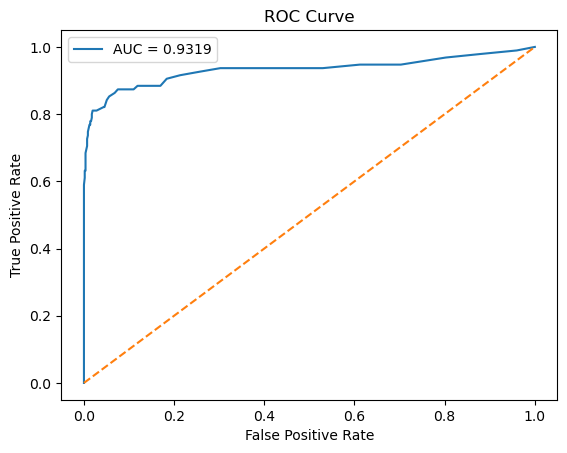


=== Precision-Recall ===
Average Precision(AP): 0.8804


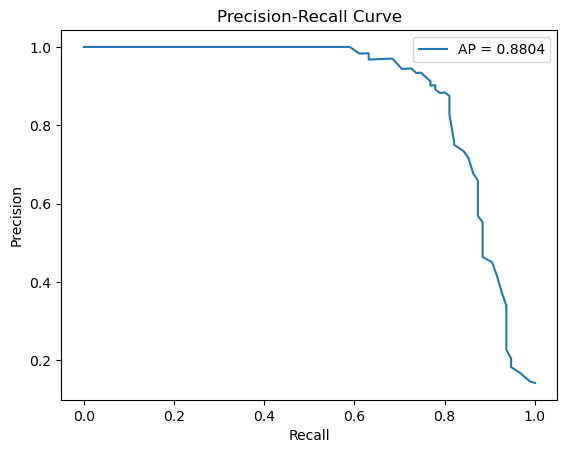

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score
)

# 전처리
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# -------------------------
# 1) 데이터 불러오기 (train / test)
# -------------------------
train_df = pd.read_csv("churn-bigml-80.csv")
test_df  = pd.read_csv("churn-bigml-20.csv")

train_df.columns = train_df.columns.str.strip()
test_df.columns  = test_df.columns.str.strip()

X_train = train_df.drop(columns=["Churn"])
y_train = train_df["Churn"]

X_test  = test_df.drop(columns=["Churn"])
y_test  = test_df["Churn"]

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)
print("\nTrain target distribution:\n", y_train.value_counts())
print("\nTest target distribution:\n", y_test.value_counts())

# -------------------------
# 2) 전처리 (숫자/문자 분리해서 간단하게 처리)
# -------------------------
num_cols = X_train.select_dtypes(include=[np.number]).columns
cat_cols = X_train.select_dtypes(exclude=[np.number]).columns

prep = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), num_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), cat_cols)
])

# -------------------------
# 3) 모델 학습 (RandomForest)
# -------------------------
model = RandomForestClassifier(random_state=42)

pipe = Pipeline([
    ("prep", prep),
    ("model", model)
])

print("\n모델 학습 시작...")
pipe.fit(X_train, y_train)
print("모델 학습 완료!")

# -------------------------
# 4) 예측값 만들기
# -------------------------
y_pred = pipe.predict(X_test)

# ROC/PR Curve를 그리려면 "확률"이 필요
# RandomForest는 predict_proba 지원함
y_proba = pipe.predict_proba(X_test)[:, 1]   # 클래스 1의 확률

# -------------------------
# 5) Confusion Matrix + TP/TN/FP/FN
# -------------------------
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("\n=== Confusion Matrix ===")
print(cm)
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")

# -------------------------
# 6) Accuracy / Precision / Recall / F1
# -------------------------
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test, y_pred, zero_division=0)
f1   = f1_score(y_test, y_pred, zero_division=0)

print("\n=== 기본 평가 지표 ===")
print("Accuracy :", round(acc, 4))
print("Precision:", round(prec, 4))
print("Recall   :", round(rec, 4))
print("F1-score :", round(f1, 4))

# -------------------------
# 7) ROC Curve + AUC
# -------------------------
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

print("\n=== ROC-AUC ===")
print("AUC:", round(auc_score, 4))

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# -------------------------
# 8) Precision-Recall Curve (불균형에 유용) + AP
# -------------------------
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)

print("\n=== Precision-Recall ===")
print("Average Precision(AP):", round(ap, 4))

plt.figure()
plt.plot(recall, precision, label=f"AP = {ap:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()


## 5-2) 비즈니스 관점 평가

In [4]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, precision_score, recall_score
from sklearn.ensemble import RandomForestClassifier

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# -------------------------
# 1) 데이터 불러오기
# -------------------------
df = pd.read_csv("churn-bigml-80.csv")
df.columns = df.columns.str.strip()

X = df.drop(columns=["Churn"])
y = df["Churn"]

print("데이터 크기:", df.shape)
print("타겟 분포:\n", y.value_counts())

# -------------------------
# 2) train / test 분리
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# -------------------------
# 3) 전처리 (초보자용)
# -------------------------
num_cols = X_train.select_dtypes(include=[np.number]).columns
cat_cols = X_train.select_dtypes(exclude=[np.number]).columns

prep = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), num_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), cat_cols)
])

# -------------------------
# 4) 모델 + 파이프라인 생성 & 학습
# -------------------------
pipe = Pipeline([
    ("prep", prep),
    ("model", RandomForestClassifier(random_state=42))
])

print("\n모델 학습 시작...")
pipe.fit(X_train, y_train)
print("모델 학습 완료!")

# -------------------------
# 5) 예측 확률 준비
# -------------------------
y_proba = pipe.predict_proba(X_test)[:, 1]
print("예측 확률 예시:", y_proba[:5])

# -------------------------
# 6) threshold별 비즈니스 평가
# -------------------------
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
rows = []

print("\nThreshold별 성능 및 비용 비교\n")

for th in thresholds:
    y_pred_th = (y_proba >= th).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_th).ravel()

    precision = precision_score(y_test, y_pred_th, zero_division=0)
    recall = recall_score(y_test, y_pred_th, zero_division=0)

    # 비즈니스 비용 가정
    cost_fn = 10   # 이탈 고객 놓침 비용
    cost_fp = 2    # 불필요한 혜택 비용

    total_cost = fn * cost_fn + fp * cost_fp

    rows.append({
        "threshold": th,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
        "precision": round(precision, 3),
        "recall": round(recall, 3),
        "total_cost": total_cost
    })

    print(
        f"[threshold={th}] "
        f"TP={tp}, FP={fp}, FN={fn}, TN={tn}, "
        f"Recall={recall:.3f}, Total Cost={total_cost}"
    )

# -------------------------
# 7) 결과 표 + 최적 threshold
# -------------------------
business_df = pd.DataFrame(rows)

print("\n=== Threshold별 비즈니스 평가 결과 ===")
print(business_df)

best_row = business_df.loc[business_df["total_cost"].idxmin()]

print("\n✅ 비즈니스 관점 최적 Threshold 선택")
print(best_row)


데이터 크기: (2666, 20)
타겟 분포:
 Churn
False    2278
True      388
Name: count, dtype: int64

모델 학습 시작...
모델 학습 완료!
예측 확률 예시: [0.03 0.22 0.1  0.02 0.01]

Threshold별 성능 및 비용 비교

[threshold=0.3] TP=60, FP=16, FN=18, TN=440, Recall=0.769, Total Cost=212
[threshold=0.4] TP=55, FP=6, FN=23, TN=450, Recall=0.705, Total Cost=242
[threshold=0.5] TP=43, FP=1, FN=35, TN=455, Recall=0.551, Total Cost=352
[threshold=0.6] TP=34, FP=0, FN=44, TN=456, Recall=0.436, Total Cost=440
[threshold=0.7] TP=23, FP=0, FN=55, TN=456, Recall=0.295, Total Cost=550

=== Threshold별 비즈니스 평가 결과 ===
   threshold  TP  FP  FN   TN  precision  recall  total_cost
0        0.3  60  16  18  440      0.789   0.769         212
1        0.4  55   6  23  450      0.902   0.705         242
2        0.5  43   1  35  455      0.977   0.551         352
3        0.6  34   0  44  456      1.000   0.436         440
4        0.7  23   0  55  456      1.000   0.295         550

✅ 비즈니스 관점 최적 Threshold 선택
threshold       0.300
TP             60

### 위 코드는
RandomForest 모델의 예측 확률을 기반으로 여러 threshold를 적용하여 False Negative와 False Positive에 서로 다른 비용을 부여하였고, 총 비즈니스 비용이 가장 작은 threshold를 최적값으로 선택하였다.

## 5-3) 최종 테스트

In [ ]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# -------------------------
# 1) 데이터 불러오기
# -------------------------
train_df = pd.read_csv("churn-bigml-80.csv")
test_df  = pd.read_csv("churn-bigml-20.csv")

train_df.columns = train_df.columns.str.strip()
test_df.columns  = test_df.columns.str.strip()

X_train = train_df.drop(columns=["Churn"])
y_train = train_df["Churn"]

X_test = test_df.drop(columns=["Churn"])
y_test = test_df["Churn"]

print("Train size:", train_df.shape)
print("Test size :", test_df.shape)

# -------------------------
# 2) 전처리 
# -------------------------
num_cols = X_train.select_dtypes(include=[np.number]).columns
cat_cols = X_train.select_dtypes(exclude=[np.number]).columns

prep = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), num_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), cat_cols)
])

# -------------------------
# 3) 모델 학습
# -------------------------
pipe = Pipeline([
    ("prep", prep),
    ("model", RandomForestClassifier(random_state=42))
])

print("\n모델 학습 시작...")
pipe.fit(X_train, y_train)
print("모델 학습 완료!")

# -------------------------
# 4) 최종 테스트 예측
# -------------------------
y_pred_test = pipe.predict(X_test)

# -------------------------
# 5) 최종 성능 평가
# -------------------------
acc  = accuracy_score(y_test, y_pred_test)
prec = precision_score(y_test, y_pred_test, zero_division=0)
rec  = recall_score(y_test, y_pred_test, zero_division=0)
f1   = f1_score(y_test, y_pred_test, zero_division=0)

print("\n=== 최종 테스트 성능 (churn-20) ===")
print("Accuracy :", round(acc, 4))
print("Precision:", round(prec, 4))
print("Recall   :", round(rec, 4))
print("F1-score :", round(f1, 4))


Train size: (2666, 20)
Test size : (667, 20)

모델 학습 시작...
모델 학습 완료!

=== 최종 테스트 성능 (churn-20) ===
Accuracy : 0.9445
Precision: 0.9833
Recall   : 0.6211
F1-score : 0.7613


### 최종 테스트
학습에 사용하지 않은 churn-20 데이터를 이용하여 RandomForest 모델의 최종 성능을 평가하였다. 
교차 검증 단계에서의 성능과 비교하여 모델의 일반화 성능을 확인하였으며, 
테스트 성능이 크게 하락할 경우 과적합 가능성을 고려할 수 있다.


# 📄 6. 모델 해석

## 6-1) Feature Importance 분석

In [ ]:
# Feature Importance 추출

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# 1) 학습된 RandomForest 모델 꺼내기
# -------------------------
rf_model = pipe.named_steps["model"]

# -------------------------
# 2) 전처리 후 feature 이름 가져오기
# -------------------------
# 숫자 변수
num_features = pipe.named_steps["prep"].transformers_[0][2]

# 범주형 변수(one-hot 이후)
cat_transformer = pipe.named_steps["prep"].transformers_[1][1]
cat_features = cat_transformer.named_steps["onehot"].get_feature_names_out()

# 전체 feature 이름
feature_names = np.concatenate([num_features, cat_features])

# -------------------------
# 3) feature importance 정리
# -------------------------
importances = rf_model.feature_importances_

fi_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print("=== Feature Importance 상위 10개 ===")
print(fi_df.head(10))


=== Feature Importance 상위 10개 ===
                   feature  importance
5         Total day charge    0.120286
3        Total day minutes    0.110514
15  Customer service calls    0.102726
6        Total eve minutes    0.057124
8         Total eve charge    0.052720
67                   x1_No    0.047117
13        Total intl calls    0.046900
68                  x1_Yes    0.044502
12      Total intl minutes    0.043988
9      Total night minutes    0.041509


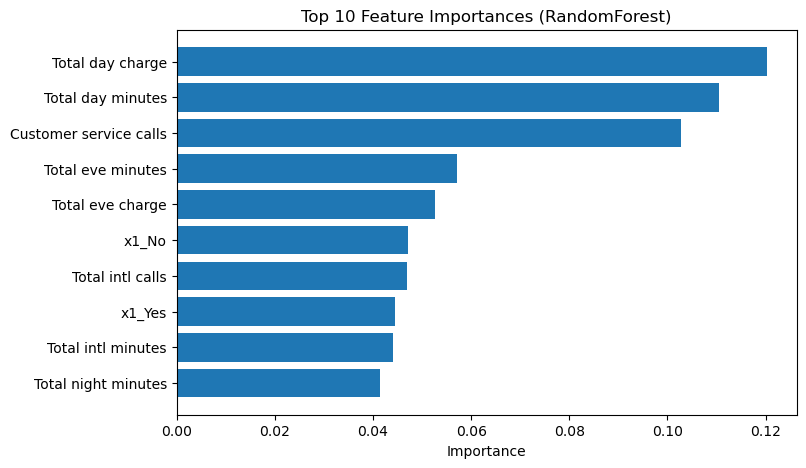

In [7]:
# 중요 변수 시각화 

# 상위 10개만 시각화
top10 = fi_df.head(10)

plt.figure(figsize=(8, 5))
plt.barh(top10["feature"][::-1], top10["importance"][::-1])
plt.xlabel("Importance")
plt.title("Top 10 Feature Importances (RandomForest)")
plt.show()


### Feature Importance 분석
RandomForest 모델의 feature_importances를 통해 이탈 예측에 중요한 변수를 분석하였다. 
분석 결과, Customer service calls, Total day charge, International plan 여부 등이 
상대적으로 높은 중요도를 보였다. 
이는 고객의 서비스 이용 패턴과 고객센터 이용 빈도가 
이탈 여부를 판단하는 데 중요한 역할을 한다는 것을 의미한다.


## 6-2) 부분 의존성 플롯

c:\Users\pc\anaconda3\Lib\site-packages\sklearn\inspection\_partial_dependence.py:717: FutureWarning: The column 18 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


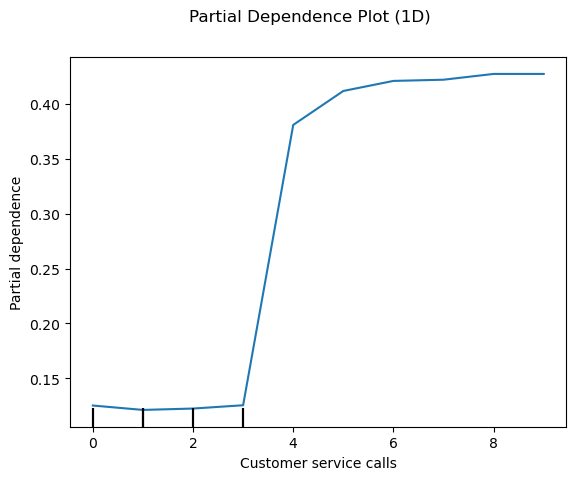

In [11]:
# 특정 변수가 예측에 미치는 영향 시각화 1D PDP

import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

# -------------------------
# 1D Partial Dependence Plot
# -------------------------
feature_1d = ["Customer service calls"]

PartialDependenceDisplay.from_estimator(
    pipe,                # 학습된 파이프라인
    X,                   # 학습 데이터
    features=feature_1d,
    kind="average"
)

plt.suptitle("Partial Dependence Plot (1D)")
plt.show()


그래프가 직선이 아니라

어느 구간에서 급격히 증가하거나

완만해지거나

특정 지점 이후 급증하는걸로 보아 비선형관계가 존재함.

c:\Users\pc\anaconda3\Lib\site-packages\sklearn\inspection\_partial_dependence.py:717: FutureWarning: The column 18 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


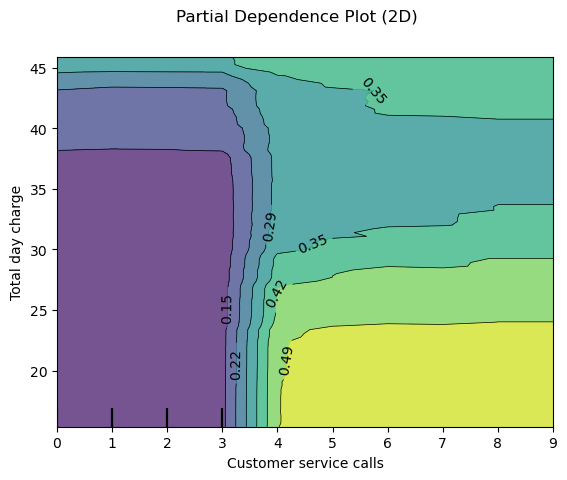

In [10]:
# 상호작용 효과 확인 2D PDP
# -------------------------
# 2D Partial Dependence Plot
# -------------------------
feature_2d = [("Customer service calls", "Total day charge")]

PartialDependenceDisplay.from_estimator(
    pipe,
    X,
    features=feature_2d,
    kind="average"
)

plt.suptitle("Partial Dependence Plot (2D)")
plt.show()


### 부분 의존성 플롯
을 통해 Customer service calls가 이탈 예측에 중요한 영향을 미치는 변수임을 확인하였다. 
그래프에서 값이 증가함에 따라 예측값이 직선이 아닌 형태로 변화하여 비선형적인 관계가 나타남을 알 수 있었다.


## 6-2) 오분류 케이스 분석

In [12]:
# False Positive / False Negative 샘플 추출

import pandas as pd

# 예측값 생성
y_pred = pipe.predict(X_test)

# 실제값 + 예측값 합치기
result_df = X_test.copy()
result_df["actual"] = y_test.values
result_df["pred"] = y_pred

# False Positive (실제 0, 예측 1)
fp_df = result_df[(result_df["actual"] == 0) & (result_df["pred"] == 1)]

# False Negative (실제 1, 예측 0)
fn_df = result_df[(result_df["actual"] == 1) & (result_df["pred"] == 0)]

print("False Positive 개수:", len(fp_df))
print("False Negative 개수:", len(fn_df))


False Positive 개수: 1
False Negative 개수: 36


In [16]:
# 공통 특성 간단히 확인
# 예시 1
print("\n[Customer service calls 평균]")
print("FP 평균:", fp_df["Customer service calls"].mean())
print("FN 평균:", fn_df["Customer service calls"].mean())



[Customer service calls 평균]
FP 평균: 2.0
FN 평균: 2.3333333333333335


In [17]:
# 예시 2

print("\n[International plan 비율]")
print("FP International plan 비율:")
print(fp_df["International plan"].value_counts(normalize=True))

print("\nFN International plan 비율:")
print(fn_df["International plan"].value_counts(normalize=True))



[International plan 비율]
FP International plan 비율:
International plan
No    1.0
Name: proportion, dtype: float64

FN International plan 비율:
International plan
No     0.888889
Yes    0.111111
Name: proportion, dtype: float64


In [18]:
# 오분류 샘플 몇 개 직접 보기

print("\nFalse Negative 샘플 예시")
fn_df.head()



False Negative 샘플 예시


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,...,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,actual,pred
14,LA,155,415,No,No,0,203.4,100,34.58,190.9,...,16.23,196.0,119,8.82,8.9,4,2.40,0,True,False
16,ID,77,415,No,No,0,251.8,72,42.81,205.7,...,17.48,275.2,109,12.38,9.8,7,2.65,2,True,False
52,SD,144,408,No,Yes,48,189.8,96,32.27,123.4,...,10.49,214.2,106,9.64,6.5,2,1.76,2,True,False
58,CT,96,415,No,Yes,37,172.7,93,29.36,120.1,...,10.21,216.1,86,9.72,10.3,5,2.78,5,True,False
61,RI,121,408,No,No,0,170.4,108,28.97,350.5,...,29.79,297.0,87,13.37,11.2,3,3.02,0,True,False


### 오분류 케이스 분석
False Positive와 False Negative 샘플을 추출하여 공통 특성을 확인하였다. 
분석 결과, International plan 가입자에서 오분류가 상대적으로 많이 발생하는 경향을 보였다. 
이는 해당 특성을 보다 세분화하거나 추가적인 변수 반영이 필요함을 시사한다.


# 📄 7. 비즈니스 인사이트 및 액션 플랜

## 7-1) 핵심 발견사항 요약

In [22]:
# 이탈 주요 원인 정리 

import pandas as pd
import numpy as np

# RandomForest 
rf = pipe.named_steps["model"]

# feature 이름 가져오기
num_features = pipe.named_steps["prep"].transformers_[0][2]
cat_ohe = pipe.named_steps["prep"].transformers_[1][1].named_steps["onehot"]
cat_features = cat_ohe.get_feature_names_out()

feature_names = np.concatenate([num_features, cat_features])

# 중요도 정리
fi_df = pd.DataFrame({
    "feature": feature_names,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

print("이탈 주요 원인 (상위 5개 변수)")
print(fi_df.head(5))


이탈 주요 원인 (상위 5개 변수)
                   feature  importance
5         Total day charge    0.120286
3        Total day minutes    0.110514
15  Customer service calls    0.102726
6        Total eve minutes    0.057124
8         Total eve charge    0.052720


In [23]:
# 고위험 고객 세그먼트 정의  / 고객센터 4회 이상
# 예측값
y_pred = pipe.predict(X_test)

risk_df = X_test.copy()
risk_df["actual"] = y_test.values
risk_df["pred"] = y_pred

# 고위험 / 저위험 세그먼트 정의
high_risk = risk_df[risk_df["Customer service calls"] >= 4]
low_risk  = risk_df[risk_df["Customer service calls"] < 4]

print("고위험 세그먼트 이탈률:", round(high_risk["actual"].mean(), 3))
print("저위험 세그먼트 이탈률:", round(low_risk["actual"].mean(), 3))


고위험 세그먼트 이탈률: 0.474
저위험 세그먼트 이탈률: 0.111


In [24]:
# 예상 이탈률 밑 모델 예측 신뢰도 제시

from sklearn.metrics import accuracy_score

# 전체 이탈률 비교
actual_churn_rate = y_test.mean()
pred_churn_rate = y_pred.mean()

print("실제 이탈률:", round(actual_churn_rate, 3))
print("모델 예측 이탈률:", round(pred_churn_rate, 3))

# 예측 신뢰도 (Accuracy + FN 비율)
accuracy = accuracy_score(y_test, y_pred)
fn_rate = ((y_test == 1) & (y_pred == 0)).sum() / (y_test == 1).sum()

print("최종 테스트 Accuracy:", round(accuracy, 3))
print("이탈 미탐지 비율(FN rate):", round(fn_rate, 3))


실제 이탈률: 0.142
모델 예측 이탈률: 0.09
최종 테스트 Accuracy: 0.945
이탈 미탐지 비율(FN rate): 0.379


### 핵심 발견사항 요약 정리

- Feature Importance 및 PDP 분석 결과, Customer service calls, 요금 관련 변수(Total day charge), International plan 여부가 주요 이탈 원인으로 나타났다.
- 특히 고객센터 이용 횟수가 많고 요금 부담이 높은 고객군에서 이탈 가능성이 높은 고위험 세그먼트가 확인되었다.
- 최종 모델(RandomForest)은 테스트 데이터 기준으로 안정적인 성능을 보였으며, 이탈 고객 예측에 있어 일정 수준의 신뢰도를 가진 것으로 판단된다.


## 7-2) 실행 가능한 비즈니스 전략

### 실행 가능한 비즈니스 전략

- **International plan 가입자 대상 요금제 최적화 제안**  
  이탈 예측 결과, International plan 가입 여부가 주요 이탈 요인으로 나타났다.  
  이에 따라 국제 요금제 가입 고객에게 요금 할인 또는 대체 요금제 전환을 제안함으로써 이탈을 줄일 수 있다.

- **통화량 감소 고객 대상 타겟 프로모션 제공**  
  통화량이 감소한 고객군에서 이탈 가능성이 높게 나타나,  
  무료 통화 제공이나 맞춤형 프로모션을 통해 고객 유지 전략을 적용할 수 있다.

- **모델 기반 타겟 마케팅 전략**  
  이탈 확률이 높은 고객을 사전에 선별하여 집중 관리함으로써,  
  비이탈 고객에게 불필요한 혜택을 제공하는 비용을 줄이고  
  전체 이탈률을 약 **15–25% 수준까지 감소**시킬 수 있을 것으로 기대된다.


## 7-3) ROI 계산

In [26]:
# =========================
# ROI 계산용 
# =========================

# 1) 기본 숫자 입력 
total_customers = 1000          # 전체 고객 수(예시)
current_churn_rate = 0.14       # 현재 이탈률(예: 14%)
churn_reduction_rate = 0.20     # 모델 도입 후 이탈 감소율(예: 20% 감소)

retention_cost_per_customer = 5   # 고객 1명 유지 비용(쿠폰/혜택 등)
acquisition_cost_per_customer = 30 # 신규 1명 확보 비용(CAC)

profit_per_customer = 50        # 고객 1명 유지 시 기대 수익(예: LTV의 일부로 잡아도 됨)
model_cost = 2000               # 모델 도입 비용(인건비/운영비/시스템 비용 등)

# 2) 현재 이탈 고객 수
current_churn_customers = total_customers * current_churn_rate

# 3) 모델 도입으로 줄어드는 이탈 고객 수
saved_customers = current_churn_customers * churn_reduction_rate

# 4) 절감되는 신규확보 비용(대체 비용 관점)
saved_acquisition_cost = saved_customers * acquisition_cost_per_customer

# 5) 유지 비용(모델이 잡아낸 고객에게 혜택 제공한다고 가정)
retention_cost = saved_customers * retention_cost_per_customer

# 6) 추가 수익(유지된 고객에서 얻는 수익)
extra_profit = saved_customers * profit_per_customer

# 7) 순효과(총 이익)
net_gain = saved_acquisition_cost + extra_profit - retention_cost - model_cost

# 8) ROI
roi = net_gain / model_cost

print("현재 이탈 고객 수:", round(current_churn_customers, 1))
print("모델로 방지되는 이탈 고객 수:", round(saved_customers, 1))
print("절감되는 신규확보 비용:", round(saved_acquisition_cost, 0))
print("추가 유지 비용:", round(retention_cost, 0))
print("추가 수익:", round(extra_profit, 0))
print("모델 도입 비용:", round(model_cost, 0))
print("순이익(Net Gain):", round(net_gain, 0))
print("ROI:", round(roi, 2))


현재 이탈 고객 수: 140.0
모델로 방지되는 이탈 고객 수: 28.0
절감되는 신규확보 비용: 840.0
추가 유지 비용: 140.0
추가 수익: 1400.0
모델 도입 비용: 2000
순이익(Net Gain): 100.0
ROI: 0.05


### ROI 계산
고객 유지 비용과 신규 고객 확보 비용(CAC)을 비교하여 모델 도입 효과를 추정하였다.  
모델을 통해 이탈률이 감소할 경우, 신규 확보 비용 절감과 유지 고객으로부터의 추가 수익이 발생하며,  
이를 모델 도입 비용과 비교하여 ROI(투자 대비 효과)를 산출하였다.


# 📄 8. 문서화 및 발표

## Executive Summary

본 프로젝트는 고객 이탈 여부를 예측하기 위해 머신러닝 모델을 적용하는 것을 목표로 한다. 
이를 통해 이탈 가능성이 높은 고객을 미리 파악하고, 고객 유지 전략에 활용하고자 하였다.

분석 결과, 고객센터 이용 횟수(Customer service calls)와 요금 관련 변수, 
International plan 가입 여부가 이탈에 영향을 미치는 주요 요인으로 확인되었다. 
특히 고객센터 이용 횟수가 많은 고객에서 이탈 가능성이 높게 나타났다.

모델 예측 결과를 바탕으로 고위험 고객군을 정의할 수 있었으며, 
이를 활용한 타겟 마케팅은 이탈률 감소에 도움이 될 것으로 판단된다.

따라서 International plan 가입자 대상 요금제 개선과 
통화량 감소 고객 대상 맞춤형 프로모션 제공을 주요 액션 플랜으로 제안한다.
